In [1]:
import pandas as pd

import matplotlib.pyplot as plt

In [2]:
smiles_importance_csv_path = r"E:\study\vntu\MAGESTY_WORK\my_github\fluoriclogppka\data\IDs_SMILES_importances_pKa_logP.csv"
smiles_starting_data = r"E:\study\vntu\MAGESTY_WORK\my_github\fluoriclogppka\data\pKa_Prediction_Starting_data_2024.01.25.csv"

df_molecules = pd.read_csv(smiles_importance_csv_path)
df_molecules_starting_data = pd.read_csv(smiles_starting_data, index_col=0)[1:]

df_molecules_starting_data['identificator'] = df_molecules_starting_data['identificator'].replace("Carboxylic acid", "Карбонові кислоти")
df_molecules_starting_data['identificator'] = df_molecules_starting_data['identificator'].replace("Primary amine", "Первинні аміни")
df_molecules_starting_data['identificator'] = df_molecules_starting_data['identificator'].replace("Secondary amine", "Вторинні аміни")

order = ["Первинні аміни", "Вторинні аміни", "Карбонові кислоти"]

df_molecules_starting_data['identificator'] = pd.Categorical(df_molecules_starting_data['identificator'], categories=order, ordered=True)
df_molecules_starting_data = df_molecules_starting_data.sort_values('identificator')

# Розподіл молекул за типом

C:\Users\p3tro\AppData\Local\Temp\ipykernel_14672\778016736.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


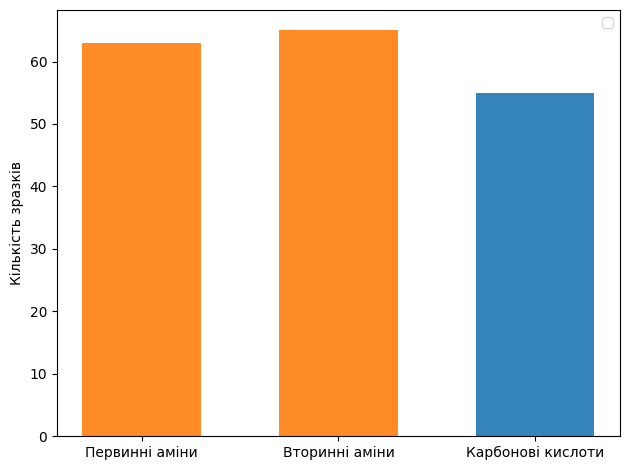

In [55]:
logp_df = df_molecules_starting_data.dropna(subset=["LogP"])

counts = logp_df["identificator"].value_counts(sort=False)

plt.bar(counts.index, counts.values, color=["#ff7f0e", "#ff7f0e", "#1f77b4"], alpha=0.9, width=0.6)

plt.ylabel("Кількість зразків")
plt.legend()
plt.tight_layout()
plt.show()


C:\Users\p3tro\AppData\Local\Temp\ipykernel_14672\2726471361.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


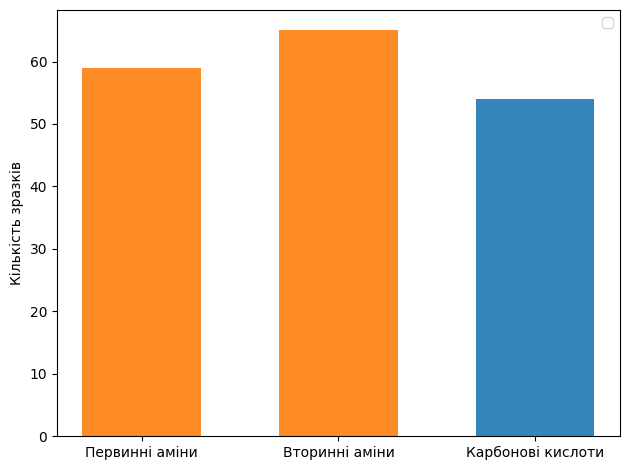

In [56]:
pka_df = df_molecules_starting_data.dropna(subset=["pKa"])

counts = pka_df["identificator"].value_counts(sort=False)

plt.bar(counts.index, counts.values, color=["#ff7f0e", "#ff7f0e", "#1f77b4"], alpha=0.9, width=0.6)

plt.ylabel("Кількість зразків")
plt.legend()
plt.tight_layout()
plt.show()

# Розподіл фторованої групи

In [60]:
counts

F group
non-F      48
gem-CF2    47
CF3        29
CHF2       25
CH2F       22
CHF        12
Name: count, dtype: int64

In [65]:
labels

Index(['non-F', 'gem-CF2', 'CF3', 'CHF2', 'CH2F', 'CHF'], dtype='object', name='F group')

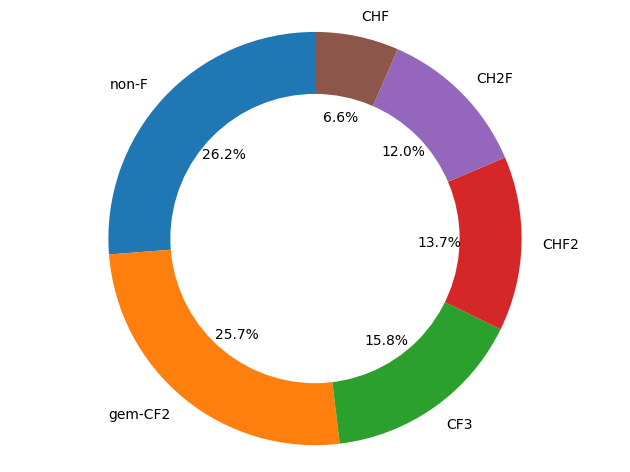

In [ ]:
counts = df_molecules_starting_data["F group"].value_counts()

labels = counts.index
sizes = counts.values

fig1, ax1 = plt.subplots()
ax1.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
#draw circle
centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
ax1.axis('equal')  
plt.tight_layout()
plt.show()

# Вплив фтору на значення logp, pka

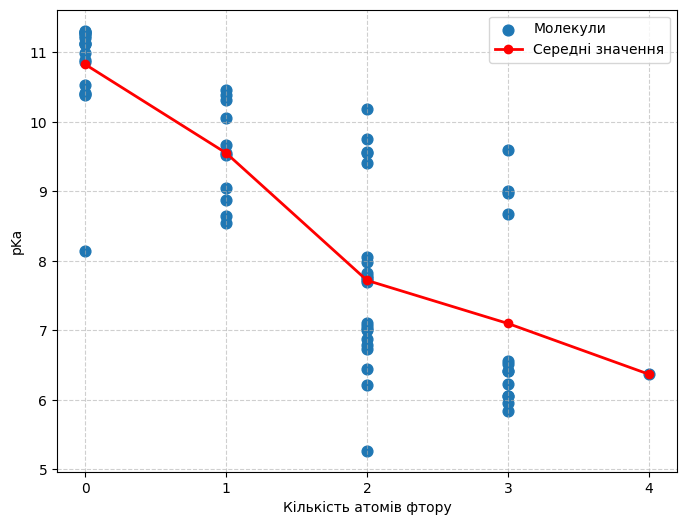

In [86]:
df_amines =  df_molecules_starting_data[df_molecules_starting_data["identificator"] == "Вторинні аміни"]

molecules = df_amines["Smiles"].to_list()
logp_values = df_amines["pKa"].to_list()

def count_f_atoms(mol):
    return mol.count('F')

f_counts = [count_f_atoms(mol) for mol in molecules]

df = pd.DataFrame({'F_atoms': f_counts, 'pKa': logp_values})

mean_values = df.groupby('F_atoms')['pKa'].mean().reset_index()

plt.figure(figsize=(8, 6))
plt.scatter(df['F_atoms'], df['pKa'], color="#1f77b4", label='Молекули', s=60)
plt.plot(mean_values['F_atoms'], mean_values['pKa'], color='red', linewidth=2, marker='o', label='Середні значення')

plt.xlabel('Кількість атомів фтору')
plt.ylabel('pKa')
# plt.title('Залежність pKa від кількості атомів фтору')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
from matplotlib.ticker import MaxNLocator
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.show()


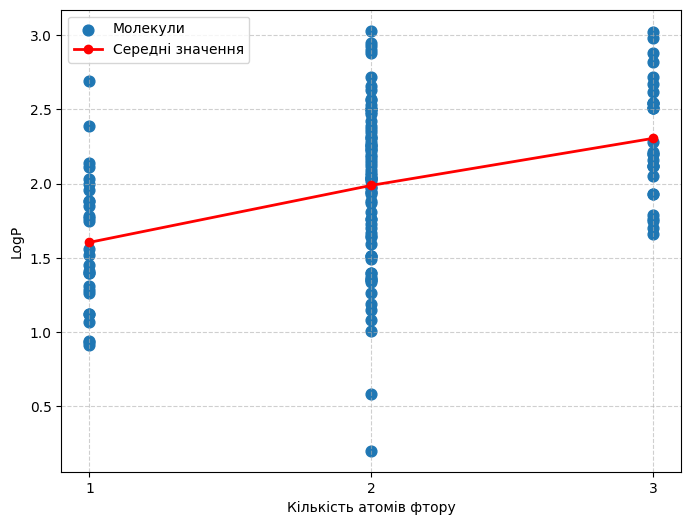

In [98]:
df_logP =  df_molecules_starting_data.copy()

molecules = df_logP["Smiles"].to_list()
logp_values = df_logP["LogP"].to_list()

def count_f_atoms(mol):
    return mol.count('F')

f_counts = [count_f_atoms(mol) for mol in molecules]

df = pd.DataFrame({'F_atoms': f_counts, 'pKa': logp_values})
df = df[df[df['F_atoms'] < 4] > 0]

mean_values = df.groupby('F_atoms')['pKa'].mean().reset_index()

plt.figure(figsize=(8, 6))
plt.scatter(df['F_atoms'], df['pKa'], color="#1f77b4", label='Молекули', s=60)
plt.plot(mean_values['F_atoms'], mean_values['pKa'], color='red', linewidth=2, marker='o', label='Середні значення')

plt.xlabel('Кількість атомів фтору')
plt.ylabel('LogP')
# plt.title('Залежність pKa від кількості атомів фтору')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
from matplotlib.ticker import MaxNLocator
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.show()


In [99]:
df_molecules_starting_data

,Reference,Smiles,LogP,pKa,Structure,MW,Amine or acid,Bemis-Murcko,Framework,F group,...,"Length of linear path, bonds",Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Atoms in ring,Amides for LogP,Unnamed: 19,F atom fraction,identificator
183,10.1002/ejoc.202200863,NC1C2(C(F)(F)C2)C1,2.04,7.44,NaN,119.115,Amine,NaN,spiro[2.2]pentane,gem-CF2,...,0,1,1,0,0,5.0,FC1(F)CC11CC1NC(=O)C1=CC=CC=C1,NaN,0.4,Первинні аміни
148,10.1002/chem.202201601,NCCC,1.72,10.03,NaN,59.112,Amine,NaN,methane,non-F,...,0,0,0,0,0,0.0,CCCNC(=O)C1=CC=CC=C1,NaN,0,Первинні аміни
146,10.1002/chem.202201601,NCCCC(F)(F)[H],1.76,10.04,NaN,109.120,Amine,NaN,methane,CHF2,...,0,0,1,0,0,0.0,[H]C(F)(F)CCCNC(=O)C1=CC=CC=C1,NaN,0.5,Первинні аміни
145,10.1002/chem.202201601,NCCCC(F)([H])[H],1.56,10.36,NaN,91.129,Amine,NaN,methane,CH2F,...,0,0,1,0,0,0.0,[H]C([H])(F)CCCNC(=O)C1=CC=CC=C1,NaN,0.25,Первинні аміни
182,10.1002/ejoc.202200863,NC1C2(CC2)C1(F)F,2.14,NaN,NaN,119.115,Amine,NaN,spiro[2.2]pentane,gem-CF2,...,1,1,0,0,0,5.0,FC1(F)C(NC(=O)C2=CC=CC=C2)C11CC1,NaN,0.4,Первинні аміни
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32,10.1002/chem.202200331,O=C(O)C1CCCC1,2.68,4.69,NaN,114.144,Acid,NaN,cyclopentane,non-F,...,0,0,0,0,0,5.0,O=C(NC1=CC=CC=C1)C1CCCC1,NaN,0,Карбонові кислоти
31,10.1002/chem.202200331,OC(C1CCC1)=O,2.26,4.50,NaN,100.117,Acid,NaN,cyclobutane,non-F,...,0,0,0,0,0,4.0,O=C(NC1=CC=CC=C1)C1CCC1,NaN,0,Карбонові кислоти
30,10.1002/chem.202200331,O=C(O)C1CC1,1.92,4.60,NaN,86.090,Acid,NaN,cyclopropane,non-F,...,0,0,0,0,0,3.0,O=C(NC1=CC=CC=C1)C1CC1,NaN,0,Карбонові кислоти
28,10.1002/chem.202200331,CC(F)(F)CCC(O)=O,2.12,4.17,NaN,138.114,Acid,NaN,methane,gem-CF2,...,0,1,0,0,0,0.0,CC(F)(F)CCC(=O)NC1=CC=CC=C1,NaN,0.4,Карбонові кислоти


# SMILES table

In [6]:
df_molecules_starting_data[["Smiles", "F group", "LogP", "pKa"]].sort_index()

,Smiles,F group,LogP,pKa
1,FC1(F)CCC(C(O)=O)CC1,gem-CF2,2.63,4.32
2,OC(C1CCCCC1)=O,non-F,2.88,4.85
3,OC([C@@H]1C[C@H]2C[C@H]2C1)=O,non-F,2.87,4.35
4,OC([C@H]1C[C@H]2C[C@H]2C1)=O,non-F,2.92,4.24
5,OC([C@H]1C[C@H]2C(F)(F)[C@H]2C1)=O,gem-CF2,2.37,3.80
...,...,...,...,...
179,FC([H])([C@@H]1C[C@H]1N)[H],CH2F,1.41,NaN
180,FC([H])([C@H]1C[C@H]1N)[H],CH2F,1.12,NaN
181,NC1C2(CC2)C1,non-F,2.08,9.41
182,NC1C2(CC2)C1(F)F,gem-CF2,2.14,NaN
